In [ ]:
!pip install -q git+https://github.com/annyms7519/gwoet.git

In [ ]:
import gwoet
print(gwoet.__version__)

In [ ]:
from sklearn.datasets import fetch_openml

X, y = fetch_openml(
    data_id=31,  # credit-g
    as_frame=True,
    return_X_y=True,
    n_retries=10,
    delay=10,
)

display(X.head())
print(y)

# Discrete Naive Bayes

y_true = ['bad' 'good' 'good' 'good' 'good' 'good' 'good' 'good' 'good' 'good'
 'good' 'bad' 'good' 'bad' 'bad' 'bad' 'good' 'good' 'bad' 'good' 'good'
 'bad' 'good' 'good' 'good' 'bad' 'good' 'good' 'good' 'good' 'good'
 'good' 'bad' 'good' 'good' 'good' 'good' 'good' 'good' 'bad' 'good'
 'good' 'good' 'good' 'good' 'good' 'bad' 'bad' 'bad' 'good' 'bad' 'good'
 'good' 'bad' 'good' 'good' 'good' 'bad' 'good' 'good' 'good' 'bad' 'bad'
 'good' 'good' 'good' 'good' 'good' 'good' 'bad' 'good' 'good' 'good'
 'good' 'good' 'bad' 'bad' 'good' 'bad' 'bad' 'good' 'good' 'good' 'good'
 'good' 'bad' 'bad' 'bad' 'good' 'good' 'good' 'good' 'bad' 'good' 'good'
 'good' 'good' 'good' 'bad' 'bad' 'good' 'bad' 'bad' 'good' 'good' 'good'
 'good' 'good' 'good' 'bad' 'bad' 'good' 'good' 'good' 'good' 'good' 'bad'
 'bad' 'good' 'good' 'good' 'good' 'good' 'good' 'bad' 'bad' 'bad' 'good'
 'good' 'good' 'good' 'bad' 'bad' 'good' 'good' 'good' 'bad' 'good' 'good'
 'good' 'bad' 'good' 'bad' 'good' 'good' 'bad'

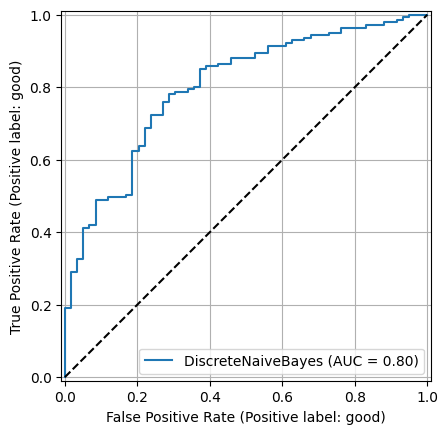

Inforvation Value (IV) =
{'checking_status': 0.5757585690219222,
 'duration': 0.21587530305596903,
 'credit_history': 0.32404559380476977,
 'purpose': 0.18368310141790017,
 'credit_amount': 0.2316540138251567,
 'savings_status': 0.13842342038319747,
 'employment': 0.07732036263949055,
 'installment_commitment': 0.0,
 'personal_status': 0.05221959932663439,
 'other_parties': 0.011544384031567215,
 'residence_since': 0.0,
 'property_magnitude': 0.133019923736729,
 'age': 0.14913584629558918,
 'other_payment_plans': 0.05709848637869645,
 'housing': 0.11890869143758233,
 'existing_credits': 0.0,
 'job': 0.018654228413876553,
 'num_dependents': 0.0,
 'own_telephone': 0.003886250060095962,
 'foreign_worker': 0.03440467620352357}


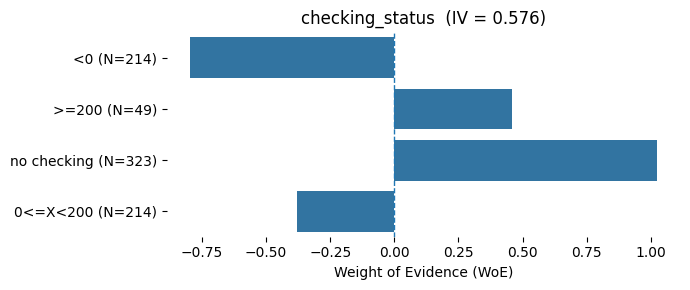

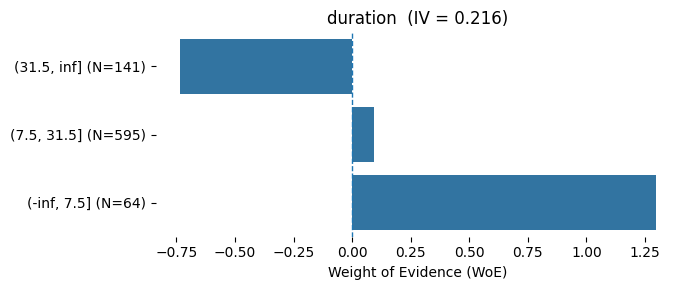

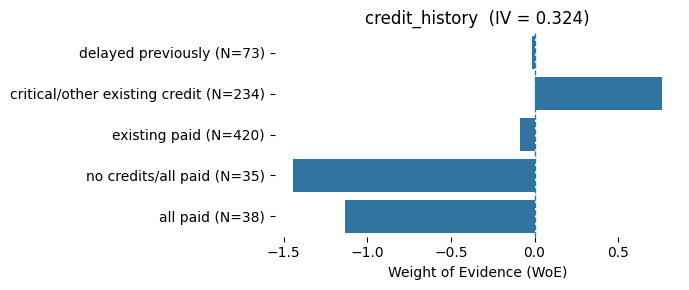

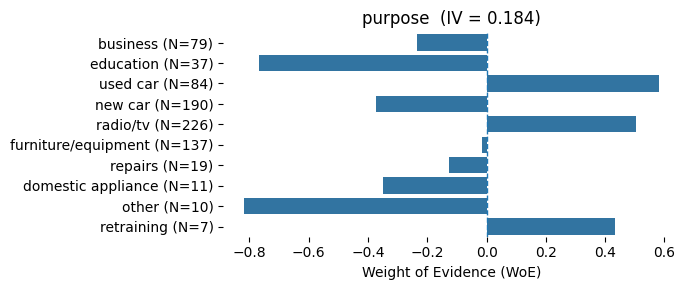

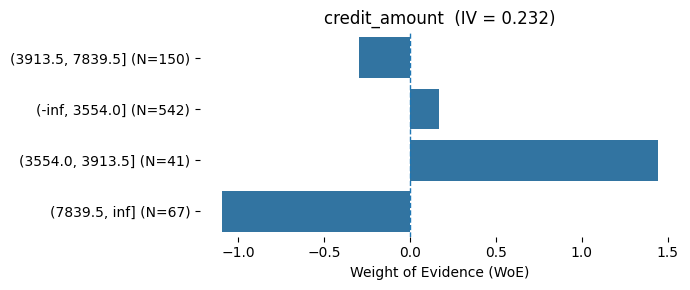

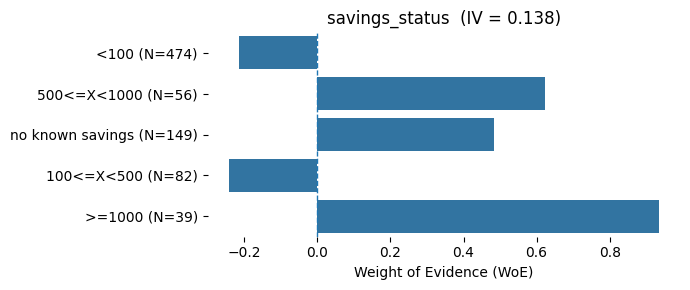

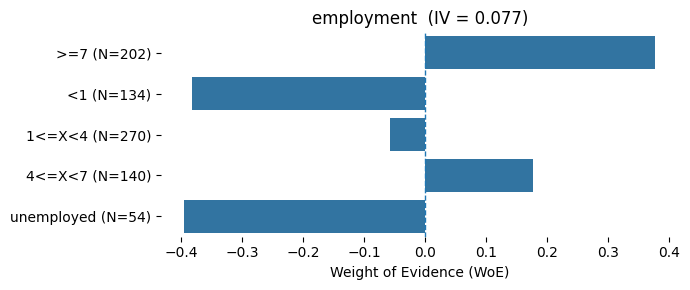

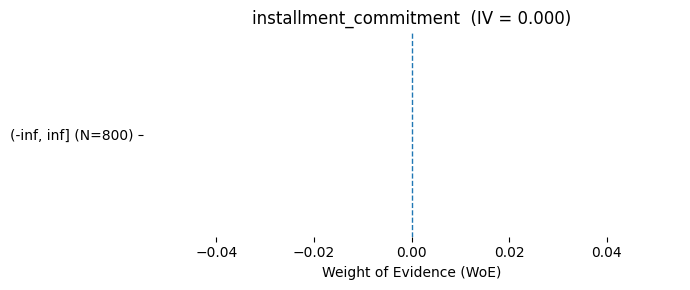

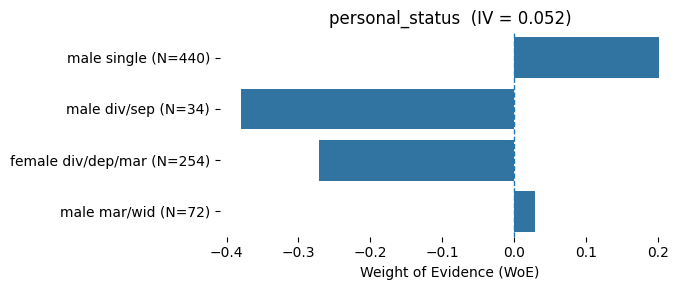

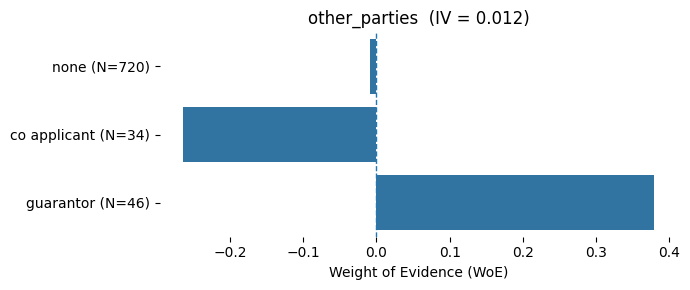

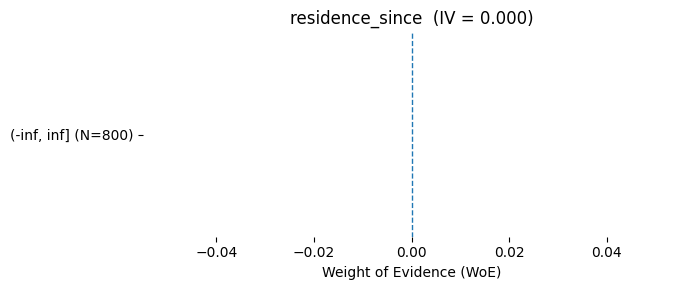

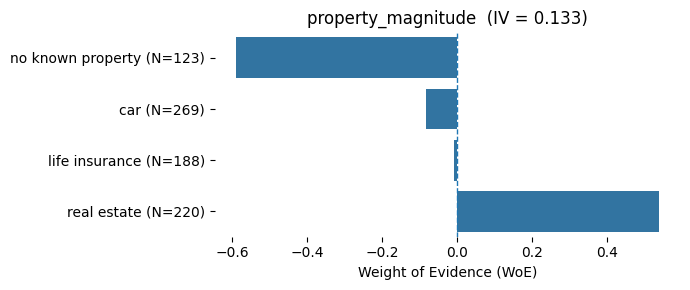

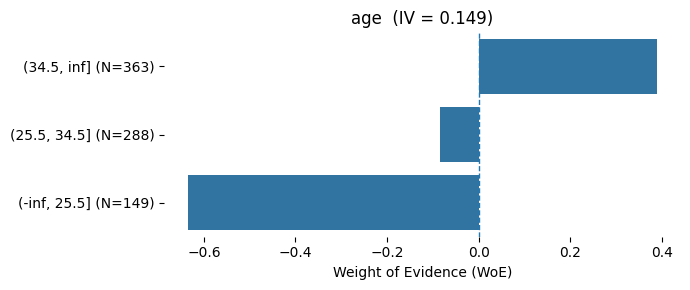

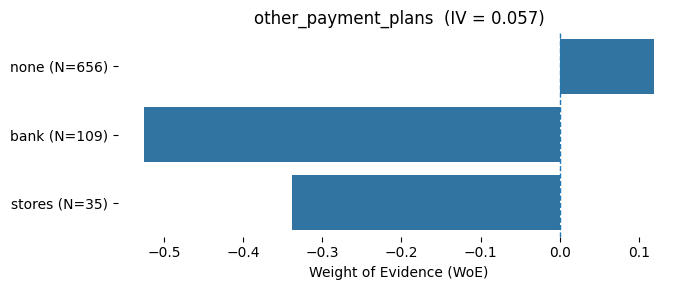

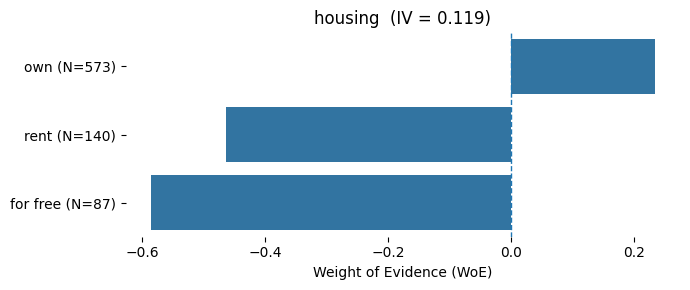

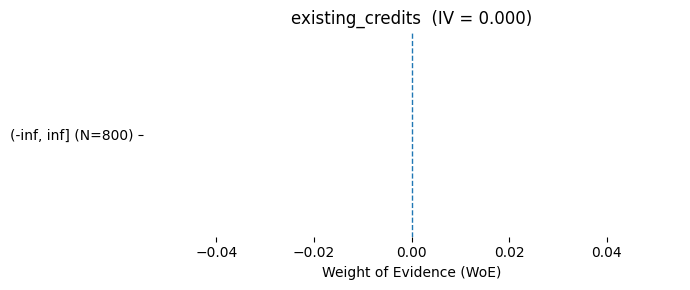

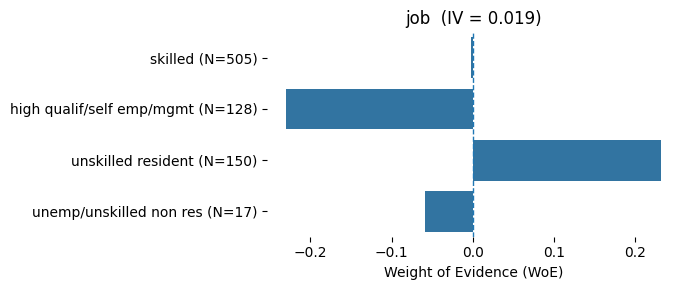

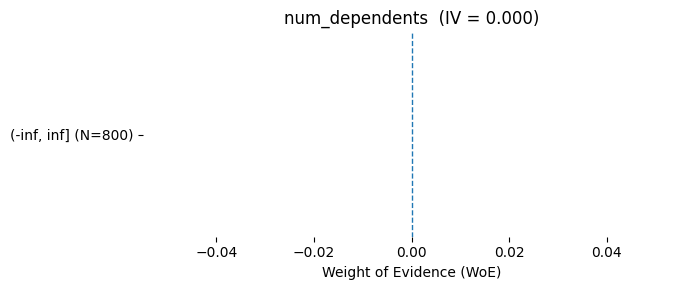

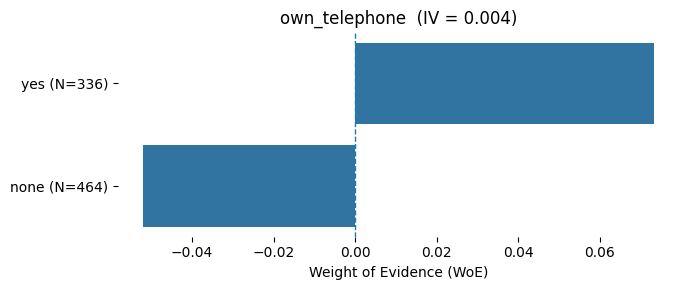

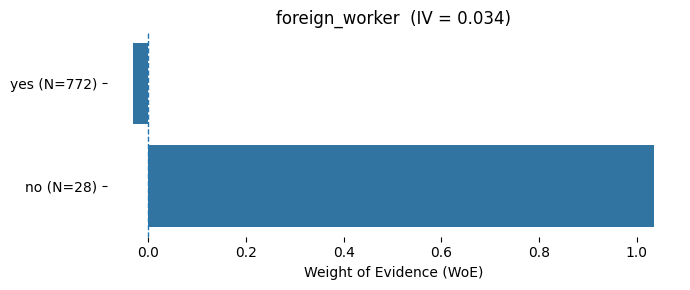

In [ ]:
import matplotlib.pyplot as plt
import pprint
from sklearn.metrics import roc_auc_score
from sklearn.metrics import RocCurveDisplay
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
)

model = DiscreteNaiveBayes()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
print(f"y_true = {y_test.to_numpy()}")
print(f"y_pred = {y_pred}")

acc_train = model.score(X_train, y_train)
acc_test = model.score(X_test, y_test)

print(f"accuracy (train): {acc_train:.3f}")
print(f"accuracy (test):  {acc_test:.3f}")

p = model.predict_proba(X_test)
auc_score = roc_auc_score(y_test.to_numpy(), p[:,1])
print(f"roc_auc_score     {auc_score:.3f}")

RocCurveDisplay.from_estimator(model, X_test, y_test)
plt.plot([0, 1], [0, 1], color="k", linestyle="--")
plt.grid()
plt.show()

iv = model.get_iv()
print("Inforvation Value (IV) =")
pprint.pp(iv)

model.plot_woe()
None

In [ ]:
import numpy as np
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import roc_auc_score

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

model = DiscreteNaiveBayes()

scores = cross_val_score(model, X, y, cv=cv)
print(f"accuracy (5-fold cv): {np.round(scores, decimals = 3)}", end = "")
print(f", mean = {scores.mean():.3f}, stdev = {scores.std():.3f}")

cv_auc = cross_val_score(model, X, y, cv=cv, scoring='roc_auc')
print(f"auc      (5-fold cv): {np.round(cv_auc, decimals = 3)}", end = "")
print(f", mean = {cv_auc.mean():.3f}, stdev = {cv_auc.std():.3f}")

accuracy (5-fold cv): [0.755 0.765 0.73  0.77  0.76 ], mean = 0.756, stdev = 0.014
auc      (5-fold cv): [0.773 0.745 0.761 0.831 0.786], mean = 0.779, stdev = 0.029



# Graphical WoE Transformer

## GWoET+DNB

Nodes: 16
target_degree = 'adaptive' -> 4
alpha=0.0038539, edges=115, mean_degree=14.375, EBIC=13246.609
alpha=0.0115617, edges=104, mean_degree=13.000, EBIC=13124.383
alpha=0.038539, edges=72, mean_degree=9.000, EBIC=12815.698
alpha=0.115617, edges=22, mean_degree=2.750, EBIC=12513.596
alpha=0.269773, edges=3, mean_degree=0.375, EBIC=12712.765
Selected by EBIC: alpha=0.115617, edges=22, mean_degree=2.750, EBIC=12513.596
Nodes after pruning: 13
Edges after pruning: 21


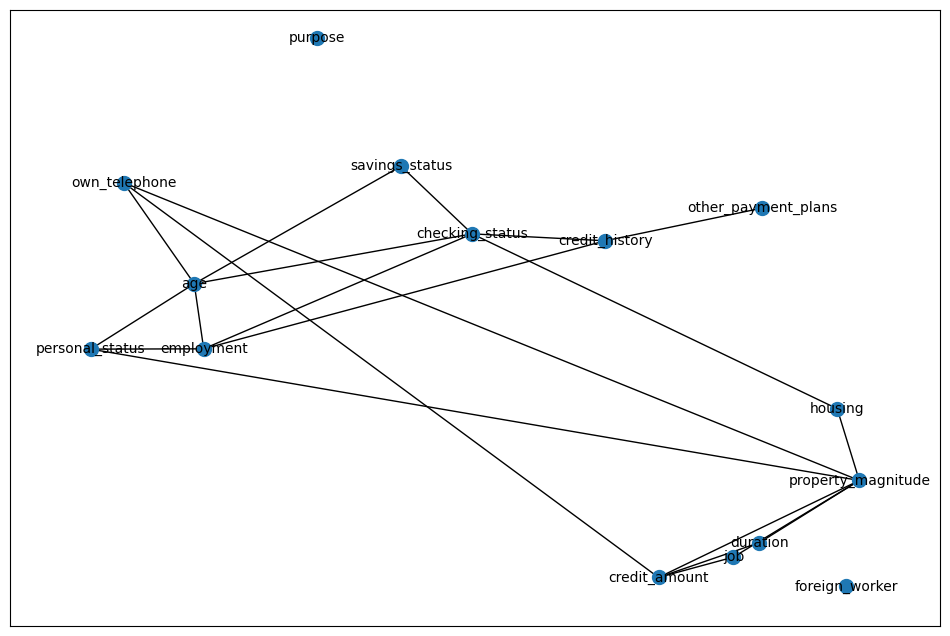

num of variables: 34


,checking_status,duration,credit_history,purpose,credit_amount,savings_status,employment,personal_status,property_magnitude,age,...,credit_amount*own_telephone,savings_status*age,employment*personal_status,employment*age,personal_status*property_magnitude,personal_status*age,property_magnitude*housing,property_magnitude*job,property_magnitude*own_telephone,age*own_telephone
29,<0,60,delayed previously,business,6836,<100,>=7,male single,no known property,63,...,"(3913.5, 7839.5]*yes","<100*(34.5, inf]",>=7*male single,">=7*(34.5, inf]",male single*no known property,"male single*(34.5, inf]",no known property*own,no known property*skilled,no known property*yes,"(34.5, inf]*yes"
535,>=200,21,critical/other existing credit,education,2319,<100,<1,male div/sep,car,33,...,"(-inf, 3554.0]*none","<100*(25.5, 34.5]",<1*male div/sep,"<1*(25.5, 34.5]",male div/sep*car,"male div/sep*(25.5, 34.5]",car*rent,car*skilled,car*none,"(25.5, 34.5]*none"
695,no checking,6,existing paid,used car,1236,500<=X<1000,1<=X<4,male single,life insurance,50,...,"(-inf, 3554.0]*none","500<=X<1000*(34.5, inf]",1<=X<4*male single,"1<=X<4*(34.5, inf]",male single*life insurance,"male single*(34.5, inf]",life insurance*rent,life insurance*skilled,life insurance*none,"(34.5, inf]*none"
557,no checking,21,no credits/all paid,new car,5003,no known savings,1<=X<4,female div/dep/mar,life insurance,29,...,"(3913.5, 7839.5]*yes","no known savings*(25.5, 34.5]",1<=X<4*female div/dep/mar,"1<=X<4*(25.5, 34.5]",female div/dep/mar*life insurance,"female div/dep/mar*(25.5, 34.5]",life insurance*own,life insurance*skilled,life insurance*yes,"(25.5, 34.5]*yes"
836,no checking,12,existing paid,radio/tv,886,no known savings,1<=X<4,female div/dep/mar,car,21,...,"(-inf, 3554.0]*none","no known savings*(-inf, 25.5]",1<=X<4*female div/dep/mar,"1<=X<4*(-inf, 25.5]",female div/dep/mar*car,"female div/dep/mar*(-inf, 25.5]",car*own,car*skilled,car*none,"(-inf, 25.5]*none"


y_true = ['bad' 'good' 'good' 'good' 'good' 'good' 'good' 'good' 'good' 'good'
 'good' 'bad' 'good' 'bad' 'bad' 'bad' 'good' 'good' 'bad' 'good' 'good'
 'bad' 'good' 'good' 'good' 'bad' 'good' 'good' 'good' 'good' 'good'
 'good' 'bad' 'good' 'good' 'good' 'good' 'good' 'good' 'bad' 'good'
 'good' 'good' 'good' 'good' 'good' 'bad' 'bad' 'bad' 'good' 'bad' 'good'
 'good' 'bad' 'good' 'good' 'good' 'bad' 'good' 'good' 'good' 'bad' 'bad'
 'good' 'good' 'good' 'good' 'good' 'good' 'bad' 'good' 'good' 'good'
 'good' 'good' 'bad' 'bad' 'good' 'bad' 'bad' 'good' 'good' 'good' 'good'
 'good' 'bad' 'bad' 'bad' 'good' 'good' 'good' 'good' 'bad' 'good' 'good'
 'good' 'good' 'good' 'bad' 'bad' 'good' 'bad' 'bad' 'good' 'good' 'good'
 'good' 'good' 'good' 'bad' 'bad' 'good' 'good' 'good' 'good' 'good' 'bad'
 'bad' 'good' 'good' 'good' 'good' 'good' 'good' 'bad' 'bad' 'bad' 'good'
 'good' 'good' 'good' 'bad' 'bad' 'good' 'good' 'good' 'bad' 'good' 'good'
 'good' 'bad' 'good' 'bad' 'good' 'good' 'bad'

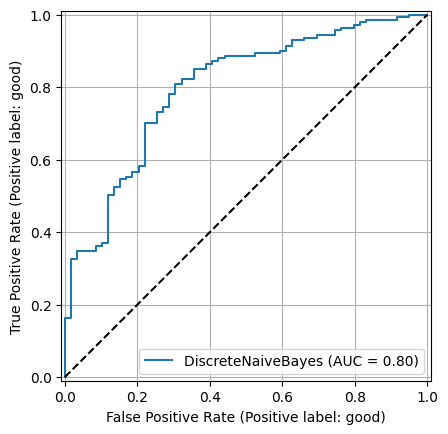

Inforvation Value (IV) =
{'checking_status': 0.5757585690219222,
 'duration': 0.21587530305596903,
 'credit_history': 0.32404559380476977,
 'purpose': 0.18368310141790017,
 'credit_amount': 0.2316540138251567,
 'savings_status': 0.13842342038319747,
 'employment': 0.07732036263949055,
 'personal_status': 0.05221959932663439,
 'property_magnitude': 0.133019923736729,
 'age': 0.14913584629558918,
 'other_payment_plans': 0.05709848637869645,
 'housing': 0.11890869143758233,
 'foreign_worker': 0.03440467620352357,
 'checking_status*credit_history': 0.8491102395541086,
 'checking_status*savings_status': 0.6654667177919066,
 'checking_status*employment': 0.7382108180328963,
 'checking_status*age': 0.6978743273429114,
 'checking_status*housing': 0.6655335016087764,
 'duration*credit_amount': 0.22867954979325283,
 'duration*property_magnitude': 0.30251733007057957,
 'credit_history*employment': 0.42641426769604507,
 'credit_history*other_payment_plans': 0.45738180013629415,
 'credit_amount*pro

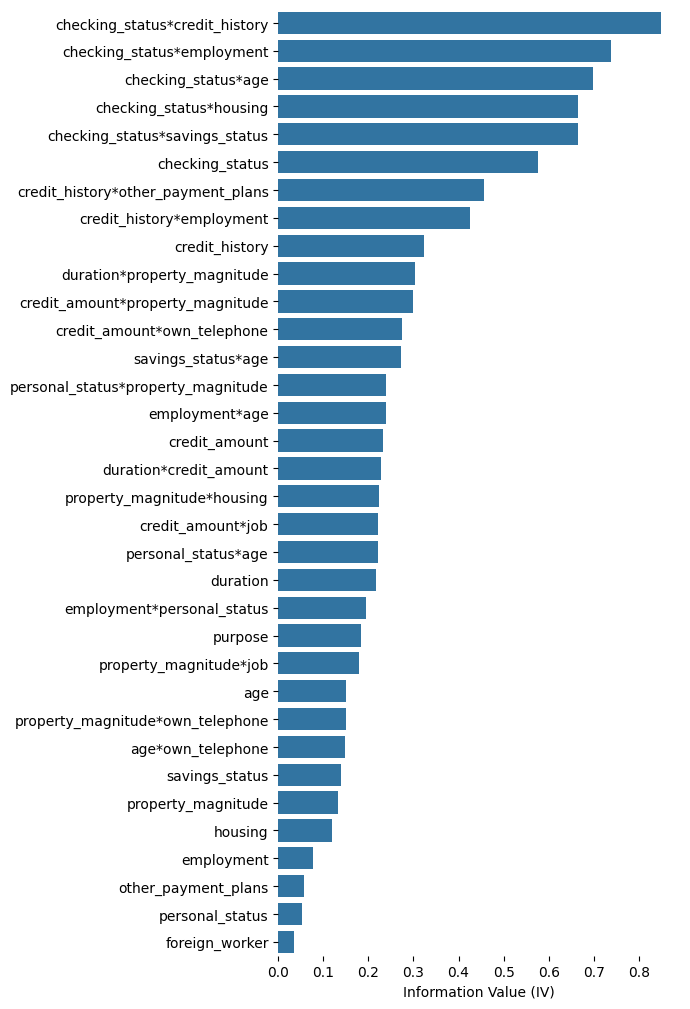

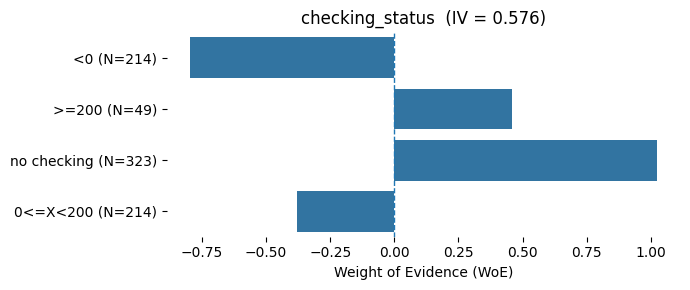

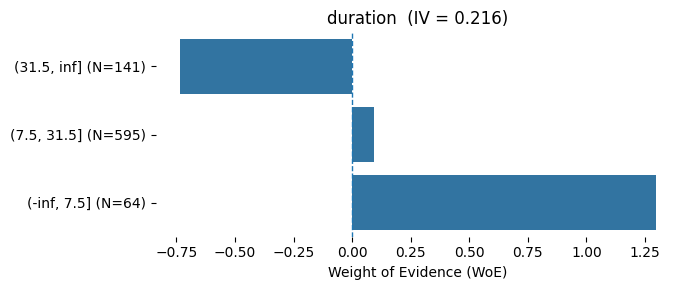

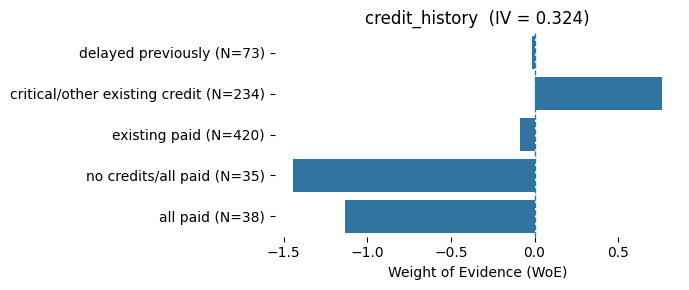

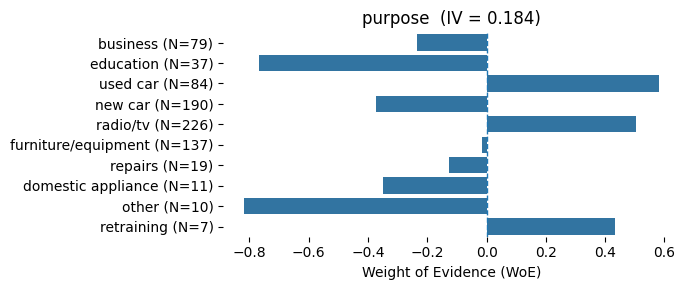

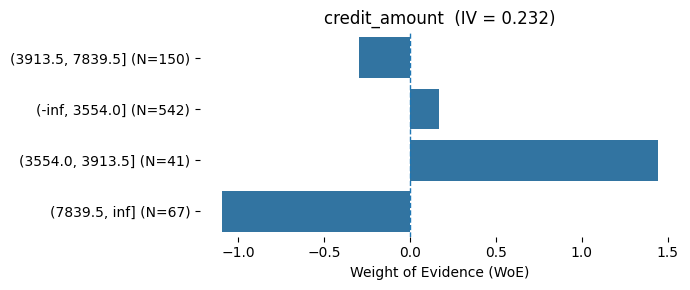

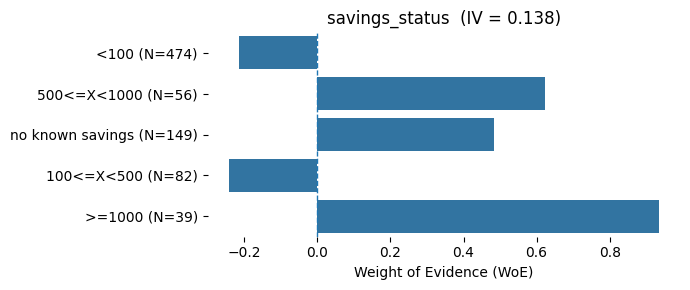

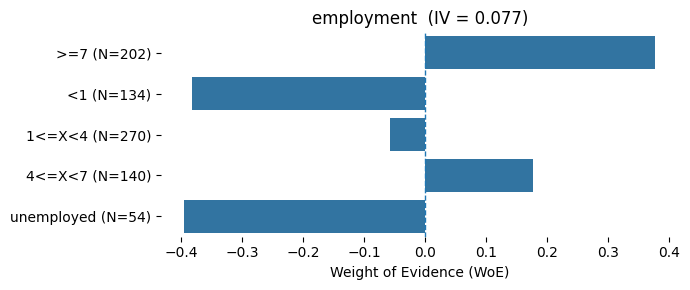

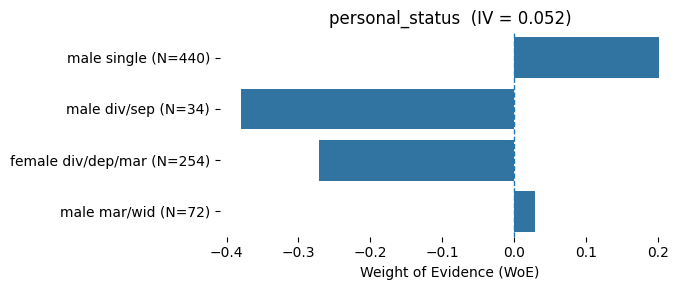

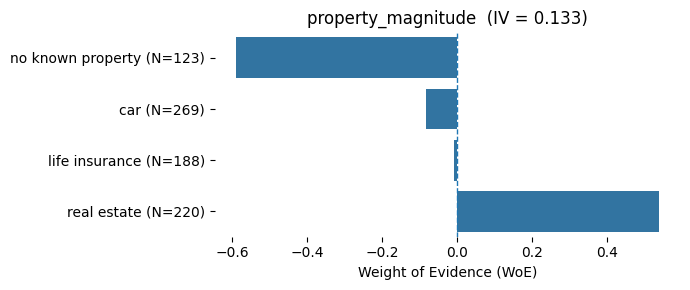

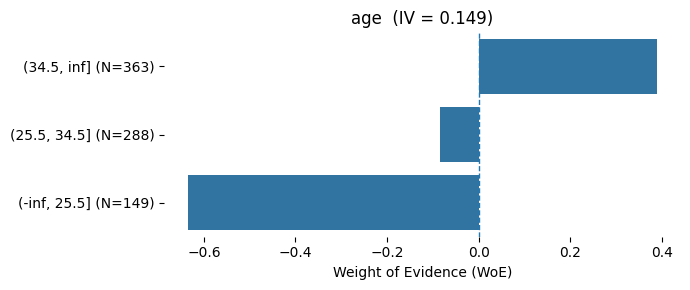

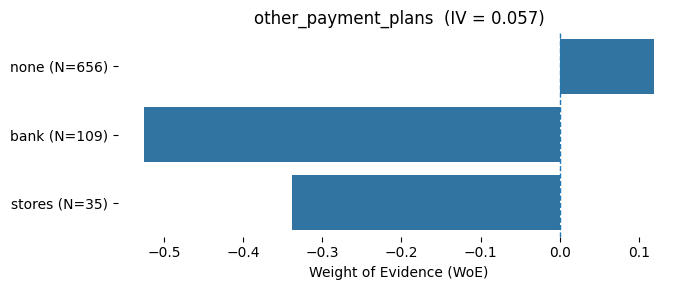

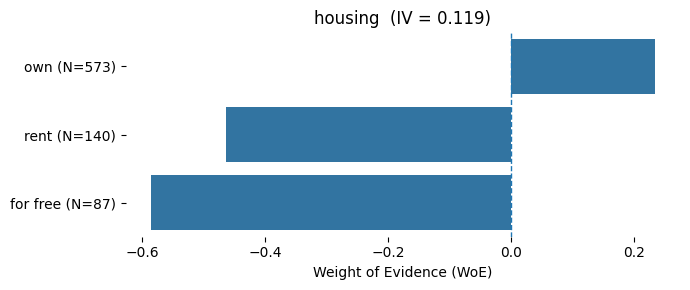

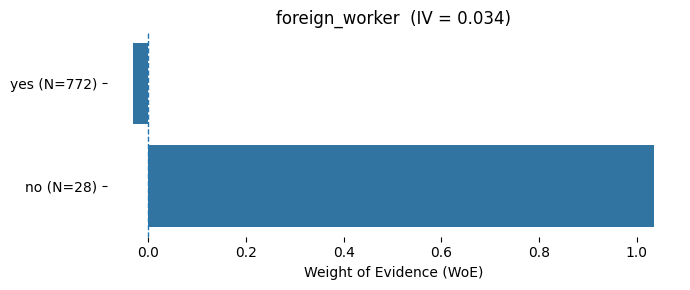

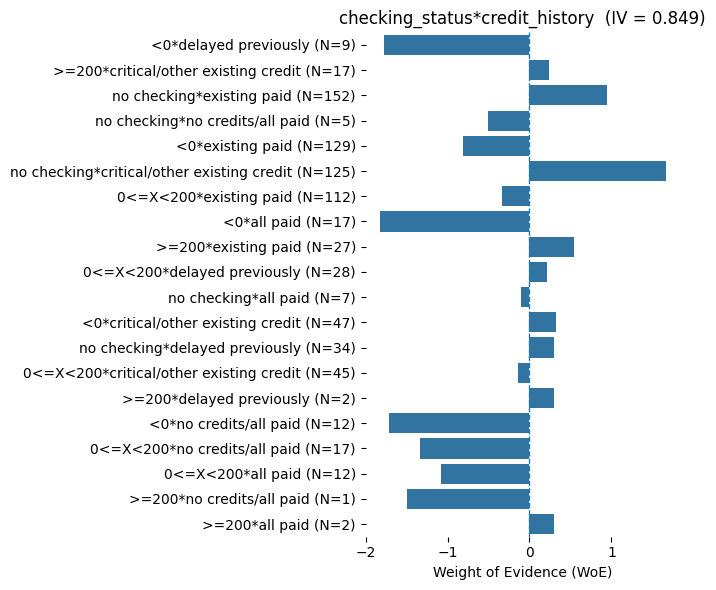

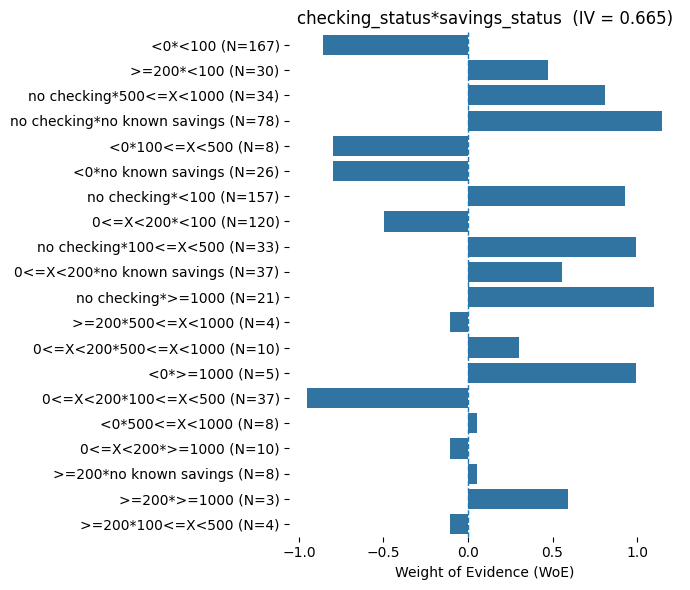

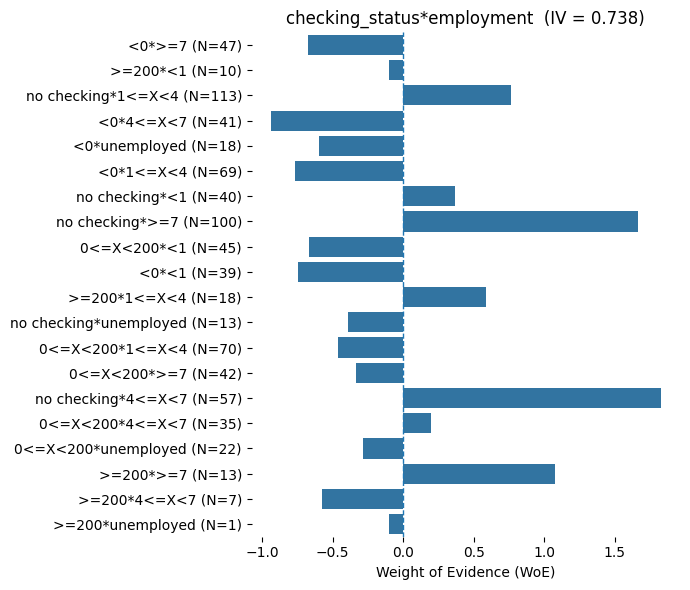

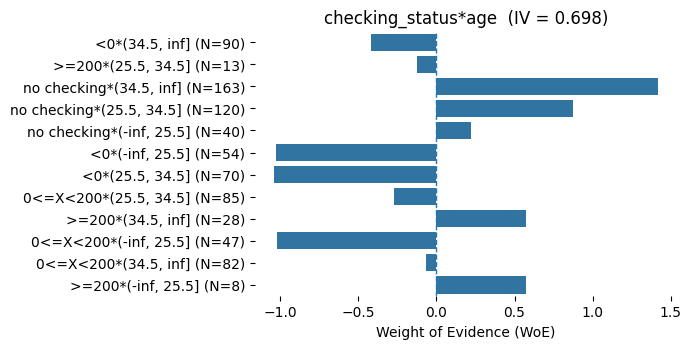

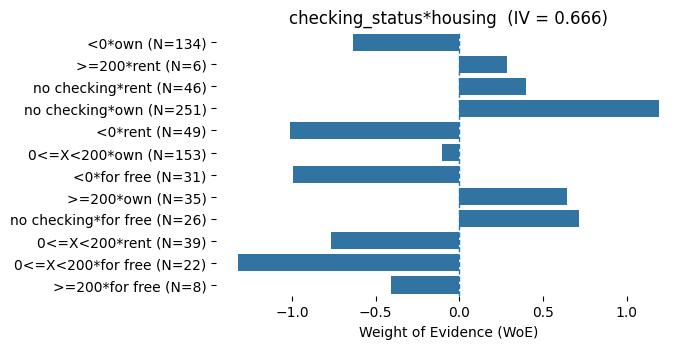

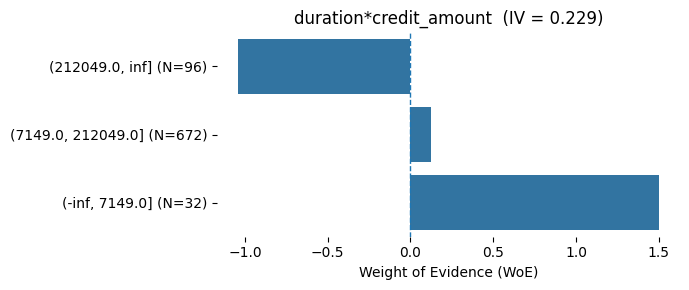

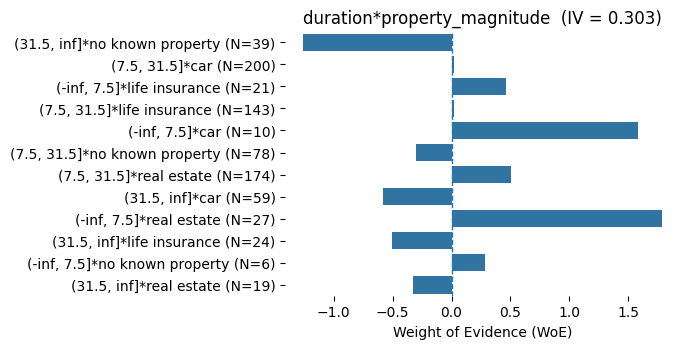

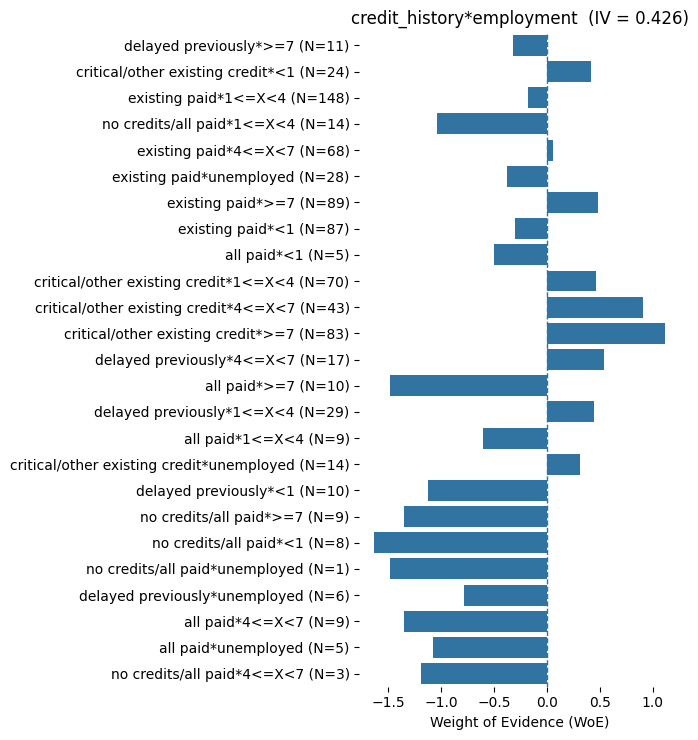

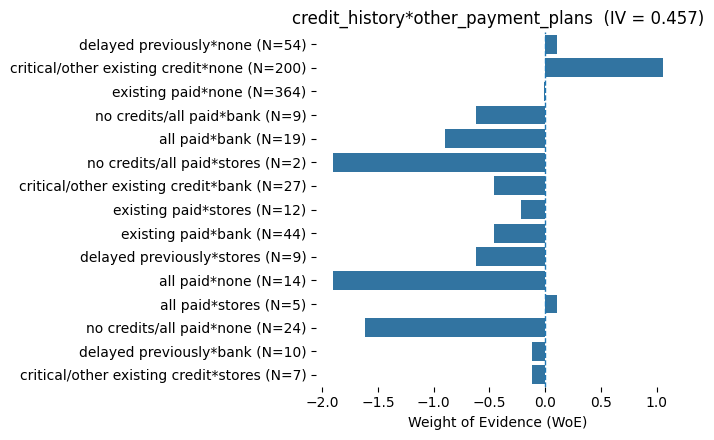

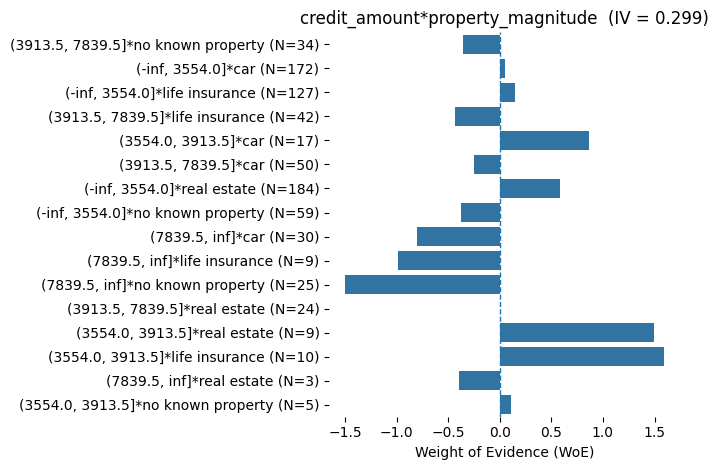

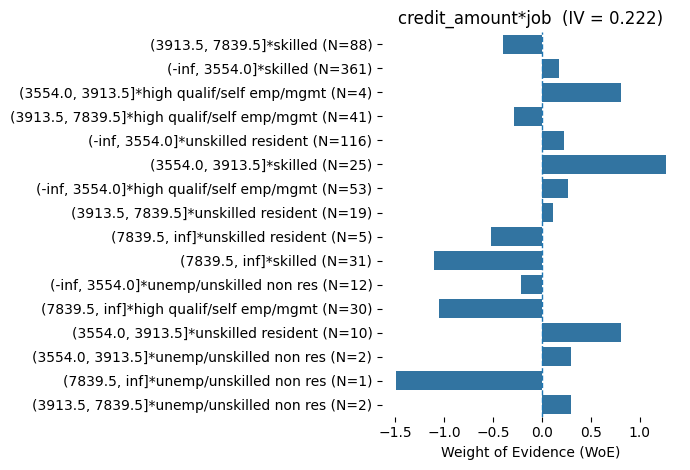

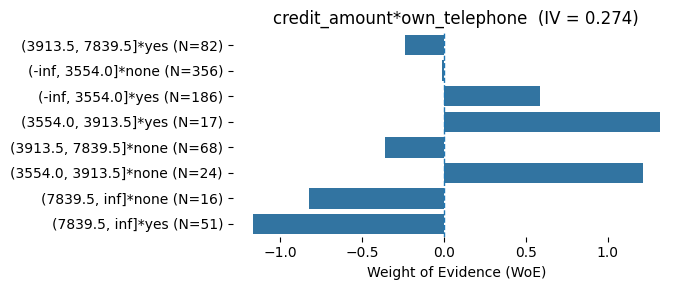

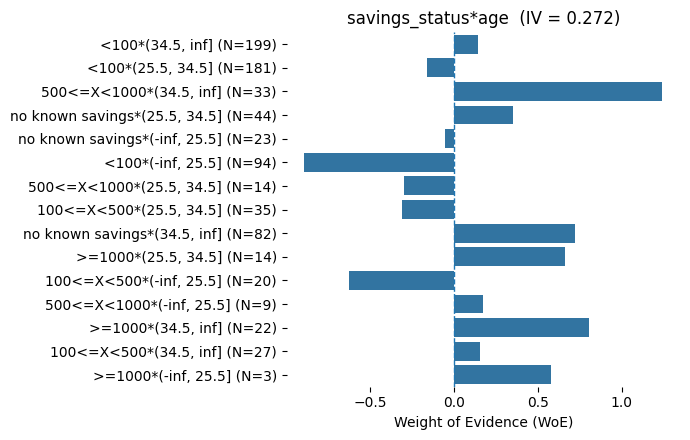

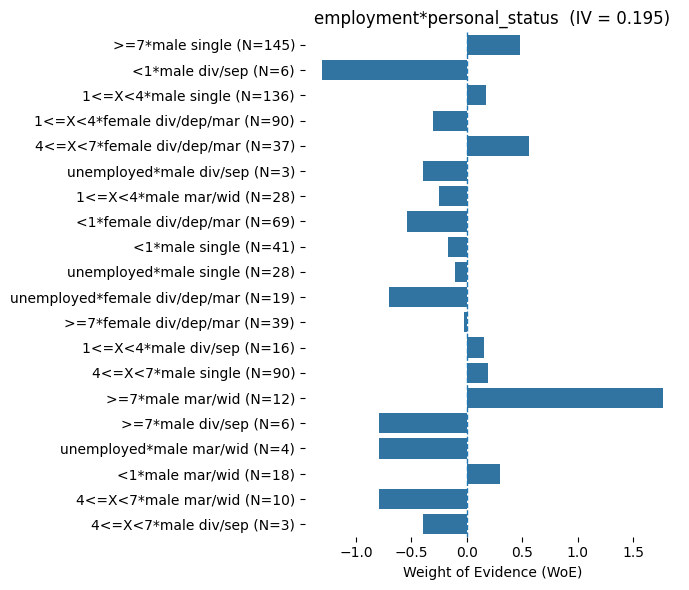

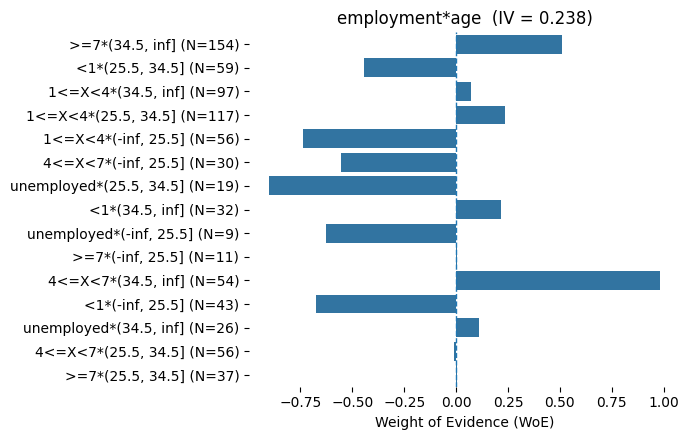

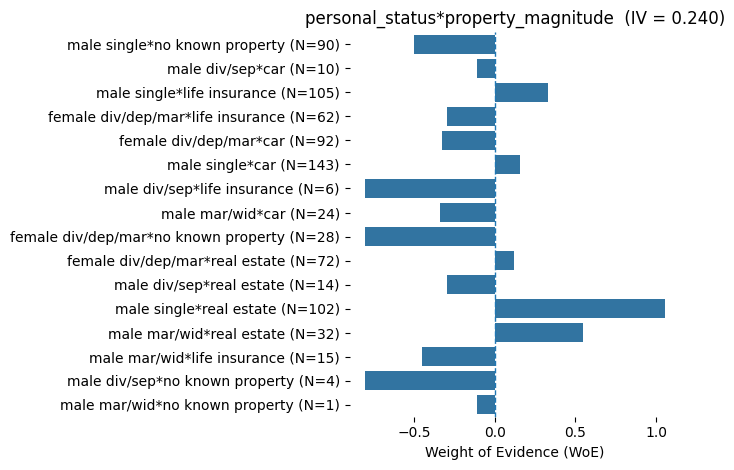

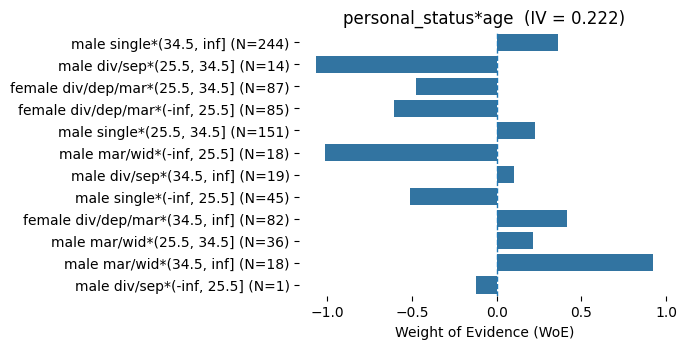

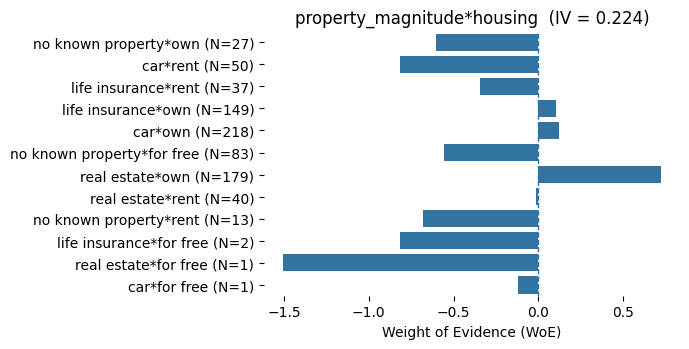

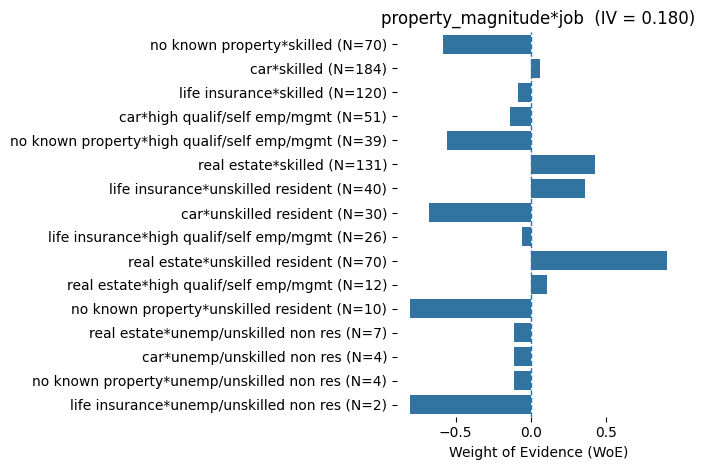

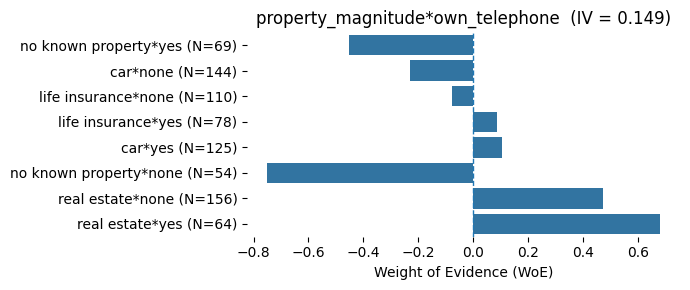

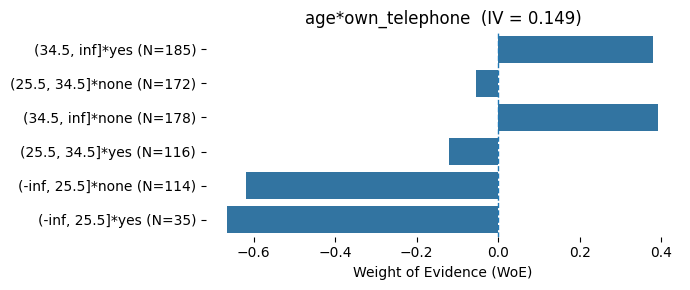

In [ ]:
import matplotlib.pyplot as plt
import pprint
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score
from sklearn.metrics import RocCurveDisplay

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
)

tfm = GraphicalWoETransformer(
    l1_selection=False,
    target_degree='adaptive',
    random_state=0,
    verbose=True,
)
tfm.fit(X_train, y_train)

plt.figure(figsize=(12, 8))
tfm.draw(node_size=100, font_size=10)

X_train_new = tfm.transform(X_train)
X_test_new = tfm.transform(X_test)
print(f"num of variables: {len(X_train_new.columns)}")
display(X_train_new.head())

model = DiscreteNaiveBayes()
model.fit(X_train_new, y_train)

y_pred = model.predict(X_test_new)
print(f"y_true = {y_test.to_numpy()}")
print(f"y_pred = {y_pred}")

acc_train = model.score(X_train_new, y_train)
acc_test = model.score(X_test_new, y_test)

print(f"accuracy (train): {acc_train:.3f}")
print(f"accuracy (test):  {acc_test:.3f}")

p = model.predict_proba(X_test_new)
auc_score = roc_auc_score(y_test.to_numpy(), p[:,1])
print(f"roc_auc_score     {auc_score:.3f}")

RocCurveDisplay.from_estimator(model, X_test_new, y_test)
plt.plot([0, 1], [0, 1], color="k", linestyle="--")
plt.grid()
plt.show()

iv = model.get_iv()
print("Inforvation Value (IV) =")
pprint.pp(iv)

model.plot_iv()
model.plot_woe()
None

In [ ]:
import numpy as np
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

model = Pipeline([
    (
        "gwoet",
        GraphicalWoETransformer(
            l1_selection=False,
            target_degree="adaptive",
            random_state=0,
        ),
    ),
    ("classifier", DiscreteNaiveBayes()),
])

scores = cross_val_score(model, X, y, cv=cv)
print(f"accuracy (5-fold cv): {np.round(scores, decimals = 3)}", end = "")
print(f", mean = {scores.mean():.3f}, stdev = {scores.std():.3f}")

cv_auc = cross_val_score(model, X, y, cv=cv, scoring='roc_auc')
print(f"auc      (5-fold cv): {np.round(cv_auc, decimals = 3)}", end = "")
print(f", mean = {cv_auc.mean():.3f}, stdev = {cv_auc.std():.3f}")

accuracy (5-fold cv): [0.77  0.755 0.715 0.745 0.76 ], mean = 0.749, stdev = 0.019
auc      (5-fold cv): [0.792 0.732 0.725 0.825 0.771], mean = 0.769, stdev = 0.037


## GWoET+L1

Nodes: 16
target_degree = 'adaptive' -> 4
alpha=0.0038539, edges=115, mean_degree=14.375, EBIC=13246.609
alpha=0.0115617, edges=104, mean_degree=13.000, EBIC=13124.383
alpha=0.038539, edges=72, mean_degree=9.000, EBIC=12815.698
alpha=0.115617, edges=22, mean_degree=2.750, EBIC=12513.596
alpha=0.269773, edges=3, mean_degree=0.375, EBIC=12712.765
Selected by EBIC: alpha=0.115617, edges=22, mean_degree=2.750, EBIC=12513.596
Nodes after pruning: 13
Edges after pruning: 21


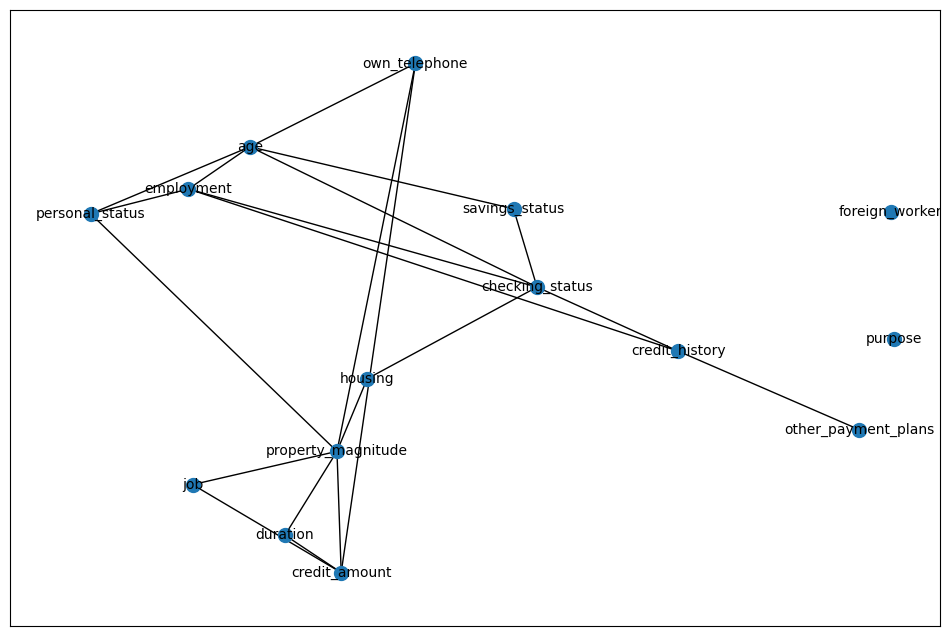

num of variables: 34


,checking_status,duration,credit_history,purpose,credit_amount,savings_status,employment,personal_status,property_magnitude,age,...,credit_amount*own_telephone,savings_status*age,employment*personal_status,employment*age,personal_status*property_magnitude,personal_status*age,property_magnitude*housing,property_magnitude*job,property_magnitude*own_telephone,age*own_telephone
29,<0,60,delayed previously,business,6836,<100,>=7,male single,no known property,63,...,"(3913.5, 7839.5]*yes","<100*(34.5, inf]",>=7*male single,">=7*(34.5, inf]",male single*no known property,"male single*(34.5, inf]",no known property*own,no known property*skilled,no known property*yes,"(34.5, inf]*yes"
535,>=200,21,critical/other existing credit,education,2319,<100,<1,male div/sep,car,33,...,"(-inf, 3554.0]*none","<100*(25.5, 34.5]",<1*male div/sep,"<1*(25.5, 34.5]",male div/sep*car,"male div/sep*(25.5, 34.5]",car*rent,car*skilled,car*none,"(25.5, 34.5]*none"
695,no checking,6,existing paid,used car,1236,500<=X<1000,1<=X<4,male single,life insurance,50,...,"(-inf, 3554.0]*none","500<=X<1000*(34.5, inf]",1<=X<4*male single,"1<=X<4*(34.5, inf]",male single*life insurance,"male single*(34.5, inf]",life insurance*rent,life insurance*skilled,life insurance*none,"(34.5, inf]*none"
557,no checking,21,no credits/all paid,new car,5003,no known savings,1<=X<4,female div/dep/mar,life insurance,29,...,"(3913.5, 7839.5]*yes","no known savings*(25.5, 34.5]",1<=X<4*female div/dep/mar,"1<=X<4*(25.5, 34.5]",female div/dep/mar*life insurance,"female div/dep/mar*(25.5, 34.5]",life insurance*own,life insurance*skilled,life insurance*yes,"(25.5, 34.5]*yes"
836,no checking,12,existing paid,radio/tv,886,no known savings,1<=X<4,female div/dep/mar,car,21,...,"(-inf, 3554.0]*none","no known savings*(-inf, 25.5]",1<=X<4*female div/dep/mar,"1<=X<4*(-inf, 25.5]",female div/dep/mar*car,"female div/dep/mar*(-inf, 25.5]",car*own,car*skilled,car*none,"(-inf, 25.5]*none"


y_true = ['bad' 'good' 'good' 'good' 'good' 'good' 'good' 'good' 'good' 'good'
 'good' 'bad' 'good' 'bad' 'bad' 'bad' 'good' 'good' 'bad' 'good' 'good'
 'bad' 'good' 'good' 'good' 'bad' 'good' 'good' 'good' 'good' 'good'
 'good' 'bad' 'good' 'good' 'good' 'good' 'good' 'good' 'bad' 'good'
 'good' 'good' 'good' 'good' 'good' 'bad' 'bad' 'bad' 'good' 'bad' 'good'
 'good' 'bad' 'good' 'good' 'good' 'bad' 'good' 'good' 'good' 'bad' 'bad'
 'good' 'good' 'good' 'good' 'good' 'good' 'bad' 'good' 'good' 'good'
 'good' 'good' 'bad' 'bad' 'good' 'bad' 'bad' 'good' 'good' 'good' 'good'
 'good' 'bad' 'bad' 'bad' 'good' 'good' 'good' 'good' 'bad' 'good' 'good'
 'good' 'good' 'good' 'bad' 'bad' 'good' 'bad' 'bad' 'good' 'good' 'good'
 'good' 'good' 'good' 'bad' 'bad' 'good' 'good' 'good' 'good' 'good' 'bad'
 'bad' 'good' 'good' 'good' 'good' 'good' 'good' 'bad' 'bad' 'bad' 'good'
 'good' 'good' 'good' 'bad' 'bad' 'good' 'good' 'good' 'bad' 'good' 'good'
 'good' 'bad' 'good' 'bad' 'good' 'good' 'bad'

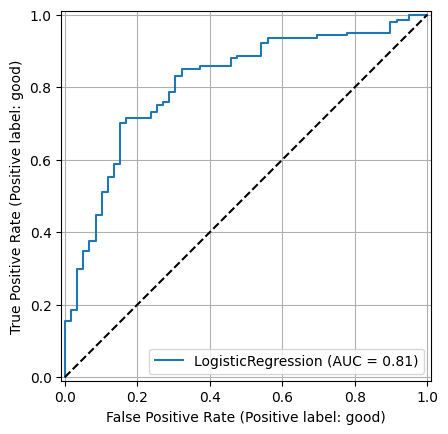

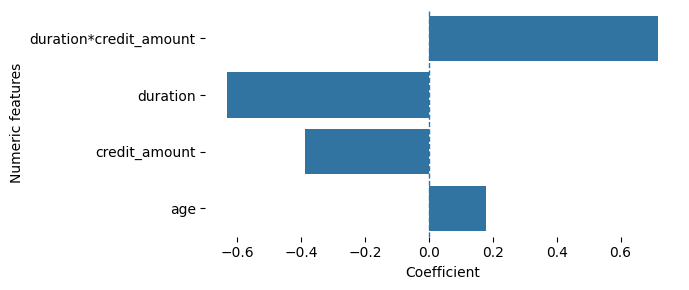

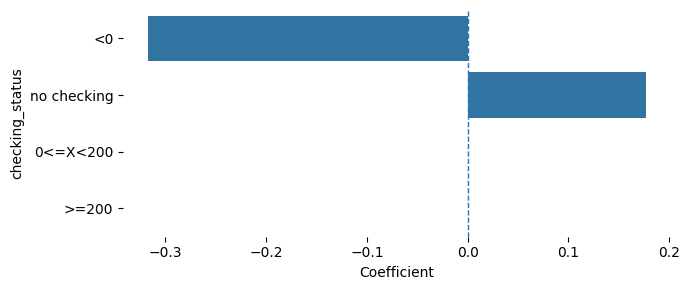

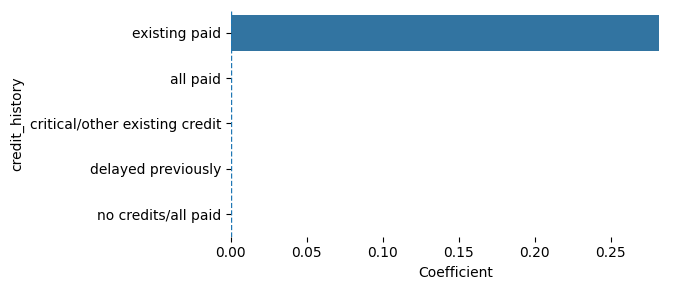

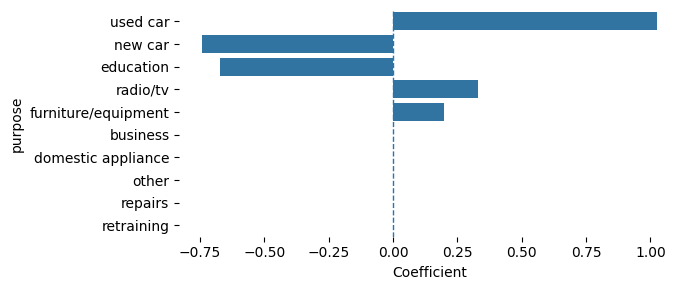

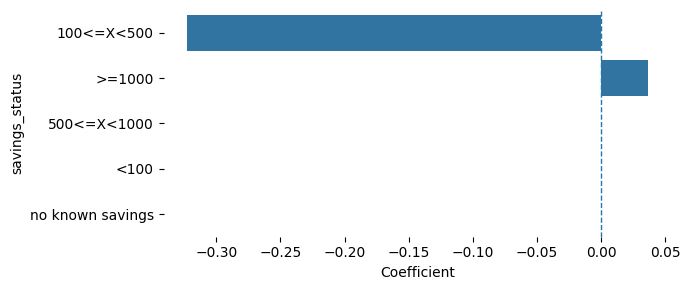

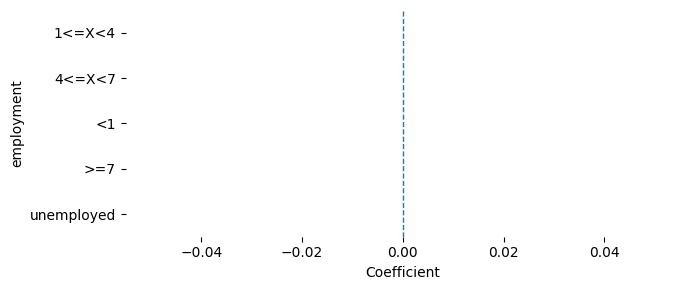

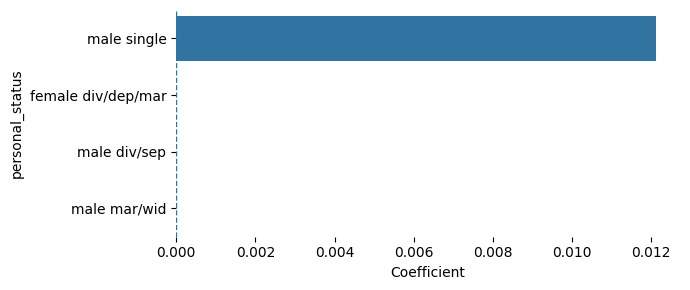

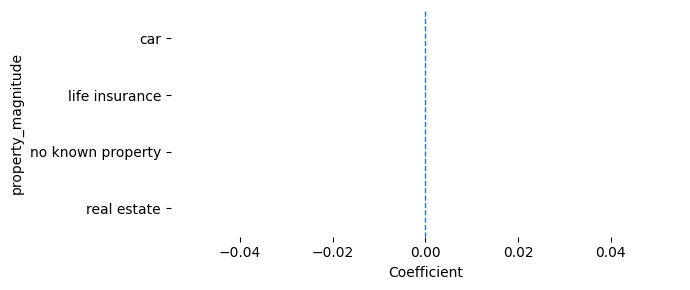

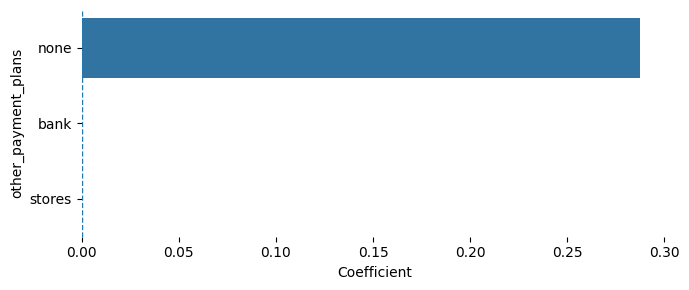

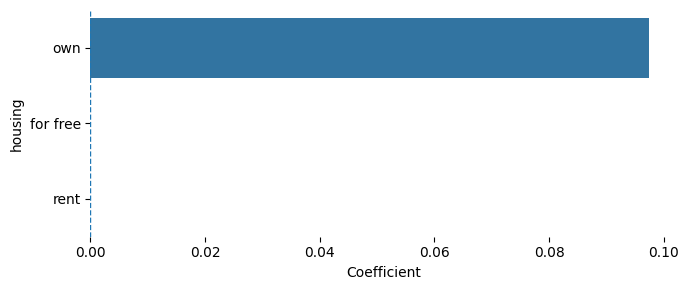

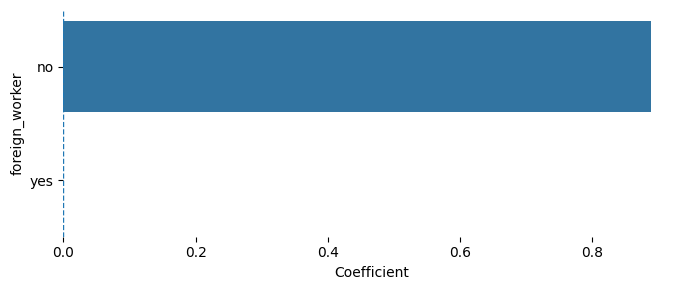

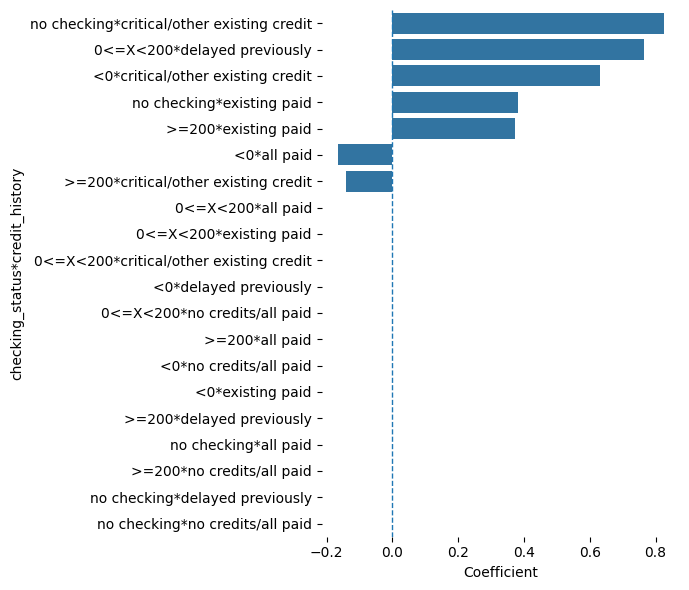

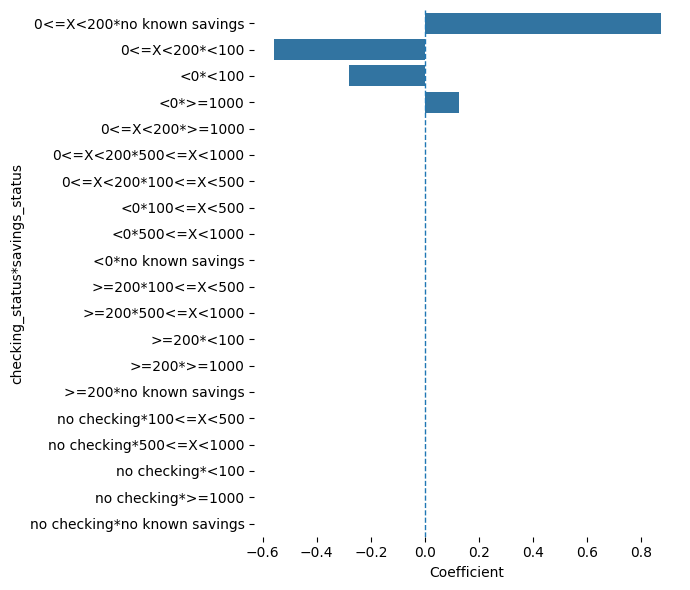

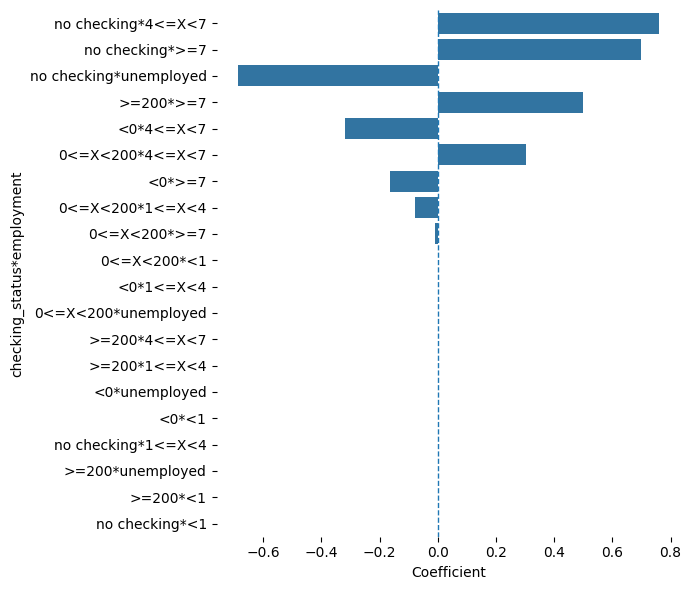

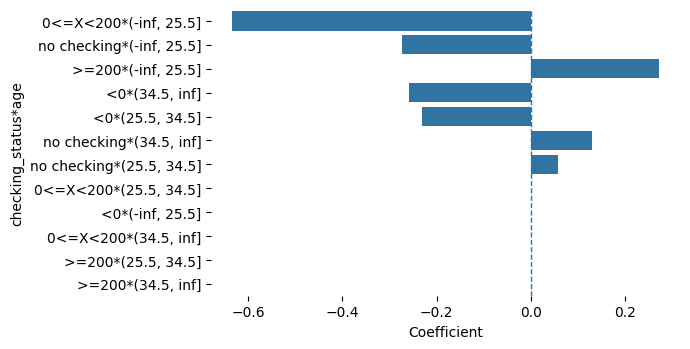

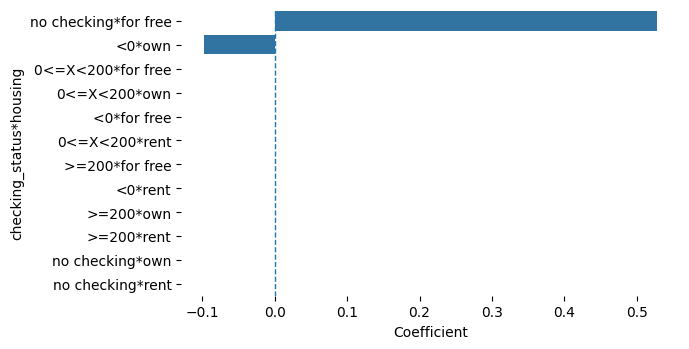

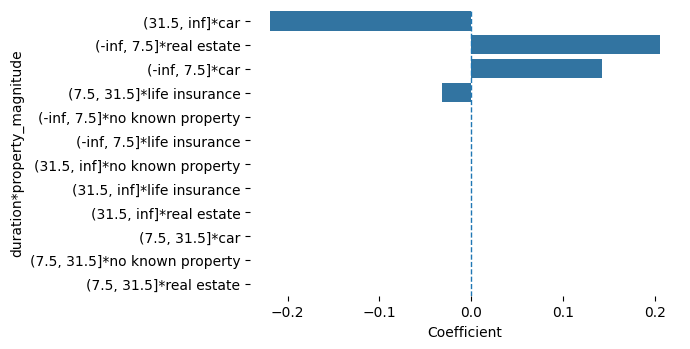

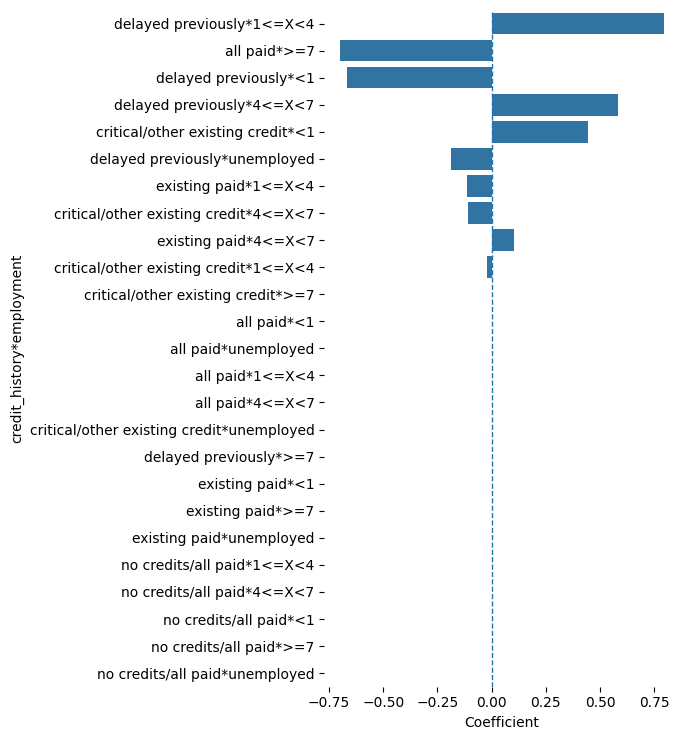

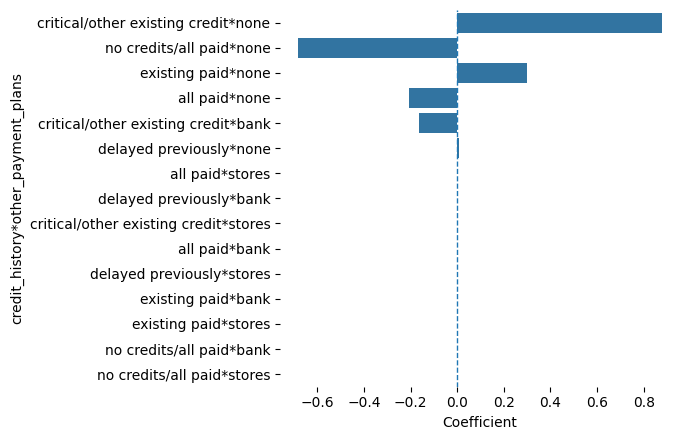

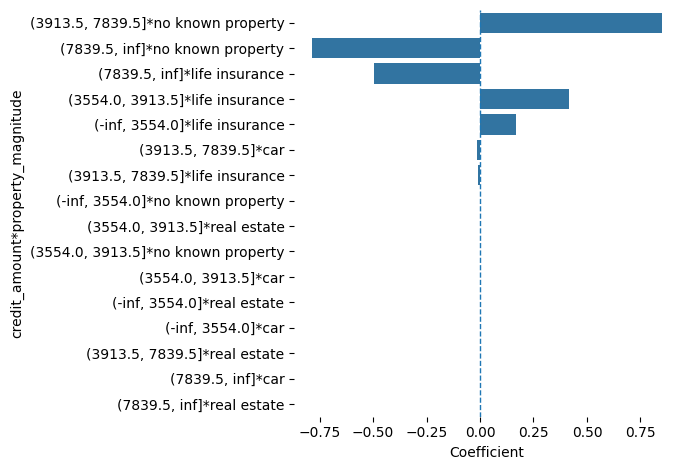

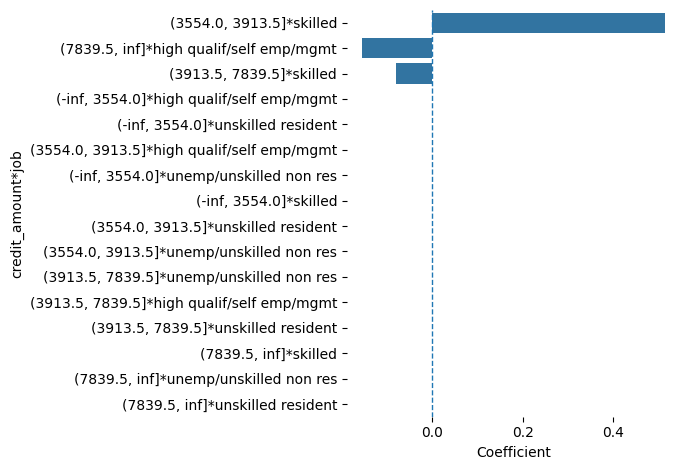

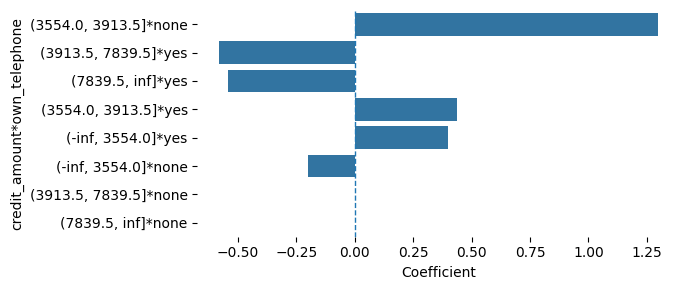

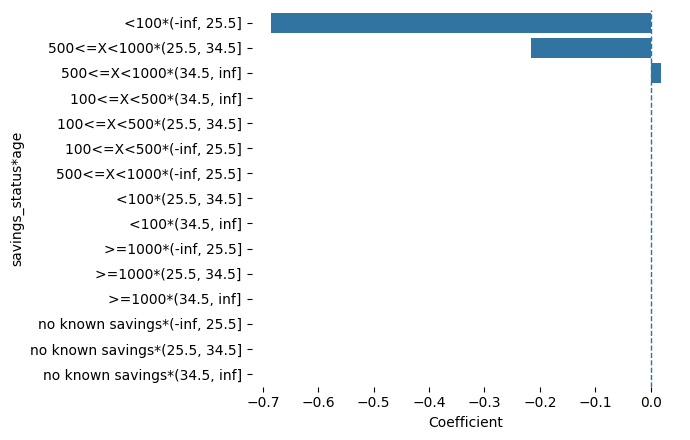

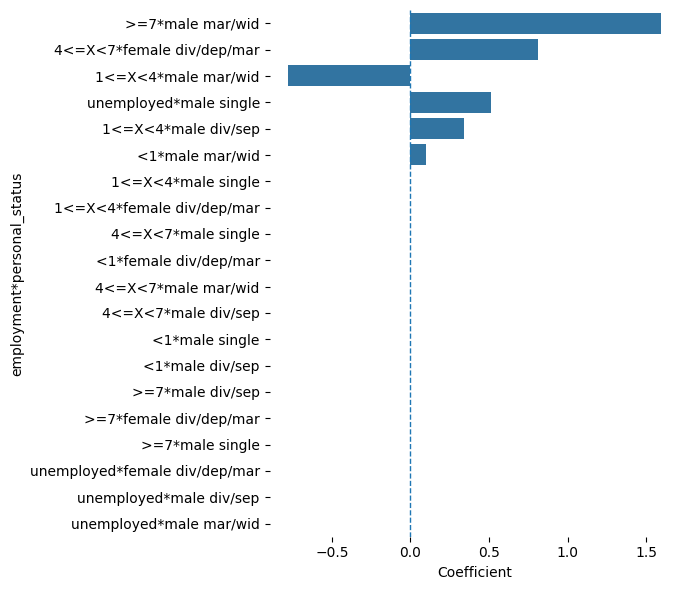

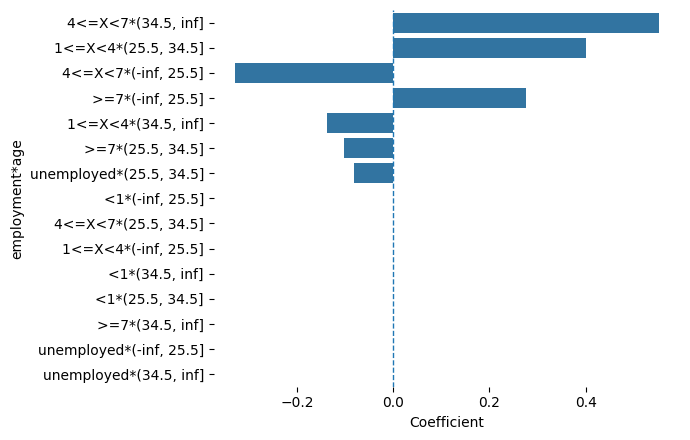

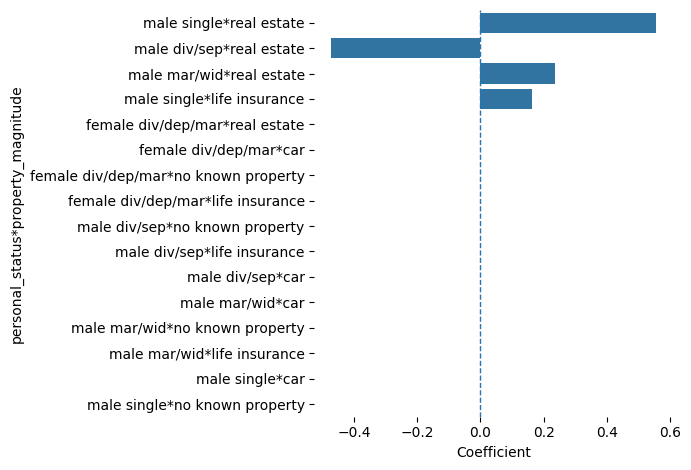

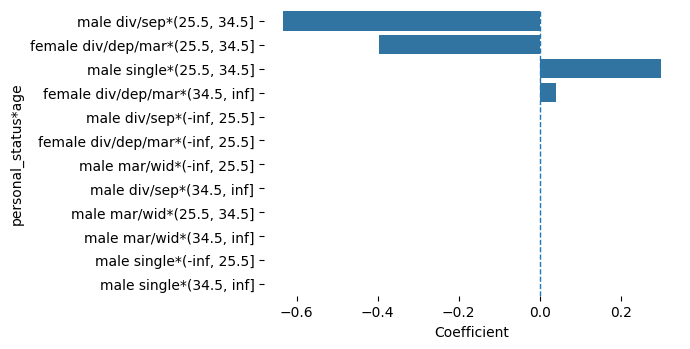

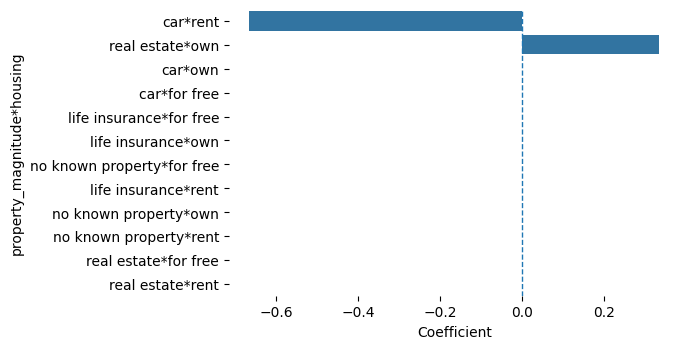

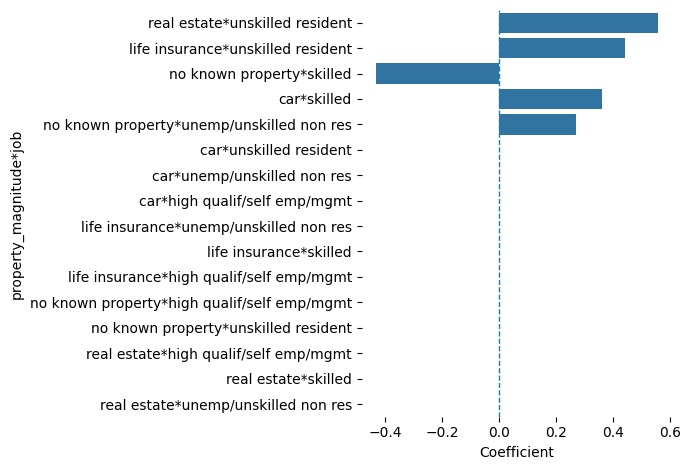

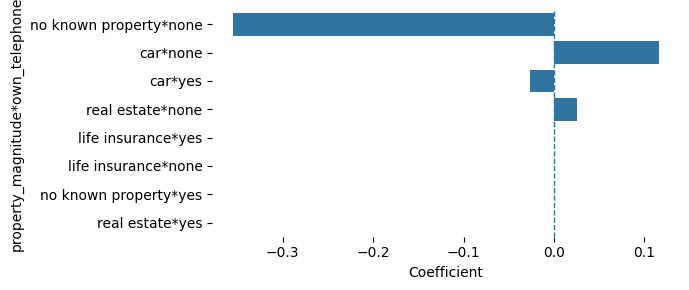

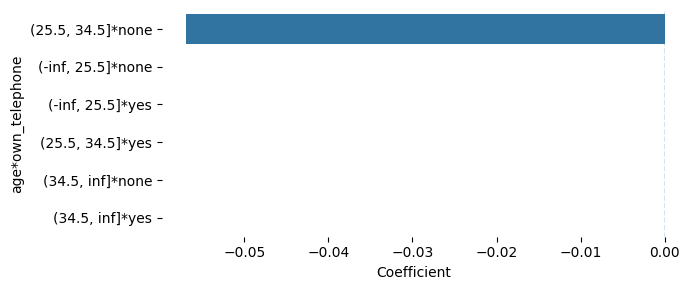

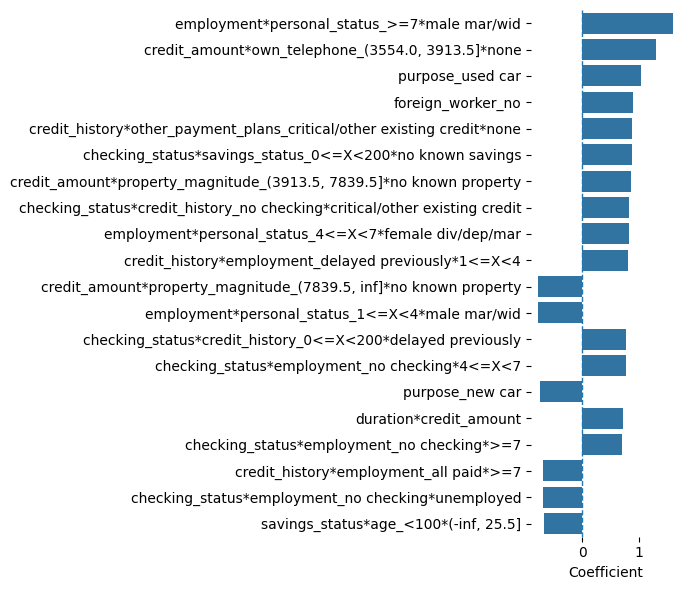

In [ ]:
import matplotlib.pyplot as plt
import pprint
from sklearn.compose import ColumnTransformer
from sklearn.compose import make_column_selector as selector
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score
from sklearn.metrics import RocCurveDisplay
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
)

tfm = GraphicalWoETransformer(
    l1_selection=False,
    target_degree='adaptive',
    random_state=0,
    verbose=True,
)
tfm.fit(X_train, y_train)

plt.figure(figsize=(12, 8))
tfm.draw(node_size=100, font_size=10)

X_train_new = tfm.transform(X_train)
X_test_new = tfm.transform(X_test)
print(f"num of variables: {len(X_train_new.columns)}")
display(X_train_new.head())

numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]
)
categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        (
            "encoder",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False,
            ),
        ),
    ]
)
column_transformer = ColumnTransformer(
    transformers=[
        (
            "num",
            numeric_transformer,
            selector(dtype_exclude=["object", "category"]),
        ),
        (
            "cat",
            categorical_transformer,
            selector(dtype_include=["object", "category"]),
        ),
    ]
)

X_train_new2 = column_transformer.fit_transform(X_train_new)
X_test_new2 = column_transformer.transform(X_test_new)

model = LogisticRegression(
    penalty='l1',
    solver='liblinear',
    C=1.0,
    random_state=0,
)

model.fit(X_train_new2, y_train)

y_pred = model.predict(X_test_new2)
print(f"y_true = {y_test.to_numpy()}")
print(f"y_pred = {y_pred}")

acc_train = model.score(X_train_new2, y_train)
acc_test = model.score(X_test_new2, y_test)

print(f"accuracy (train): {acc_train:.3f}")
print(f"accuracy (test):  {acc_test:.3f}")

p = model.predict_proba(X_test_new2)
auc_score = roc_auc_score(y_test.to_numpy(), p[:,1])
print(f"roc_auc_score     {auc_score:.3f}")

RocCurveDisplay.from_estimator(model, X_test_new2, y_test)
plt.plot([0, 1], [0, 1], color="k", linestyle="--")
plt.grid()
plt.show()

coef = make_l1_coefficient_dict(
    model,
    column_transformer,
    X_train_new,
)

plot_l1_coefficients(
    coef,
    exclude_zero=False,
)

feature_names = (
    column_transformer
    .get_feature_names_out()
)
# Remove prefixes such as "num__" and "cat__"
feature_names = [
    name.split("__", 1)[-1]
    for name in feature_names
]

coef_table = plot_l1_feature_coefficients(
    model.coef_[0],
    feature_names,
    top_n=20,
    exclude_zero=True,
)

In [ ]:
import numpy as np
from sklearn.compose import ColumnTransformer
from sklearn.compose import make_column_selector as selector
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]
)
categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        (
            "encoder",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False,
            ),
        ),
    ]
)
column_transformer = ColumnTransformer(
    transformers=[
        (
            "num",
            numeric_transformer,
            selector(dtype_exclude=["object", "category"]),
        ),
        (
            "cat",
            categorical_transformer,
            selector(dtype_include=["object", "category"]),
        ),
    ]
)

model = Pipeline([
    (
        "gwoet",
        GraphicalWoETransformer(
            l1_selection=False,
            target_degree='adaptive',
            random_state=0,
        ),
    ),
    ("preprocessor", column_transformer),
    (
        "classifier",
        LogisticRegression(
            penalty="l1",
            solver="liblinear",
            C=1.0,
            random_state=0,
        ),
    ),
])

scores = cross_val_score(model, X, y, cv=cv)
print(f"accuracy (5-fold cv): {np.round(scores, decimals = 3)}", end = "")
print(f", mean = {scores.mean():.3f}, stdev = {scores.std():.3f}")

cv_auc = cross_val_score(model, X, y, cv=cv, scoring='roc_auc')
print(f"auc      (5-fold cv): {np.round(cv_auc, decimals = 3)}", end = "")
print(f", mean = {cv_auc.mean():.3f}, stdev = {cv_auc.std():.3f}")

accuracy (5-fold cv): [0.78  0.745 0.745 0.775 0.765], mean = 0.762, stdev = 0.015
auc      (5-fold cv): [0.763 0.762 0.761 0.803 0.775], mean = 0.773, stdev = 0.016
